In [11]:
import matplotlib
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv('supermarket_sales.csv')

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [3]:
data.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [14]:
data.nunique()

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Total                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

In [15]:
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M').dt.time

In [16]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [18]:
data['Date'] = pd.to_datetime(data['Date'])

In [17]:
data.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   str           
 1   Branch                   1000 non-null   str           
 2   City                     1000 non-null   str           
 3   Customer type            1000 non-null   str           
 4   Gender                   1000 non-null   str           
 5   Product line             1000 non-null   str           
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[us]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-null   str  

In [20]:
data.describe()

,Unit price,Quantity,Tax 5%,Total,Date,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905,15.379369,6.97270
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905,49.650000,10.00000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,0.000000,11.708825,1.71858


Overview of the data
- 1000 entries across 17 columns.
- data is across 3 cities and branches. We have 6 product lines
- we have 2 customer types
- the sales span from 1st January to March 2019

What do we want to investigate

**Sales & revenue analysis**
- Total revenue/gross income by branch, city, or product line
- Best- and worst-performing product lines by revenue and quantity sold
- Average transaction value (Total) overall and by segment
- Revenue trends over time (daily, weekly, monthly patterns from Date)
- Peak sales hours/times of day (from Time)

**Customer analysis**
- Spending patterns by Customer type (Member vs Normal)
- Spending patterns by Gender
- Which product lines appeal to which customer segments (cross-tab of Gender/Customer type × Product line)
- Customer satisfaction (Rating) by branch, product line, or customer type

**Branch/location performance**
- Revenue, quantity, and rating comparison across Branch/City
- Which branch is most profitable (using cogs vs gross income)
- Branch performance over time

**Payment behavior**
- Preferred Payment method (cash, credit card, e-wallet) overall and by segment
- Does payment method correlate with spend amount or product line?

**Profitability**
- Since gross margin percentage is constant across all rows, it's not useful for comparison — but gross income and cogs let you compute margins by product line/branch if needed
- Tax paid (Tax 5%) as a check/derived field from Total

**Time-based patterns**
- Sales by day of week — good for staffing/inventory planning
- Sales by hour — identify peak shopping windows
- Combine Date + Time for a full time-series view

**Correlation/statistical**
- Does higher Unit price or Quantity correlate with Rating?
- Any relationship between Customer type and Rating (are members more satisfied)?

Univariate Analysis - Summaries, totals,
Multivariate Analysis -
Bivariate Analysis -

In [21]:
data['Payment'].describe()

count        1000
unique          3
top       Ewallet
freq          345
Name: Payment, dtype: object

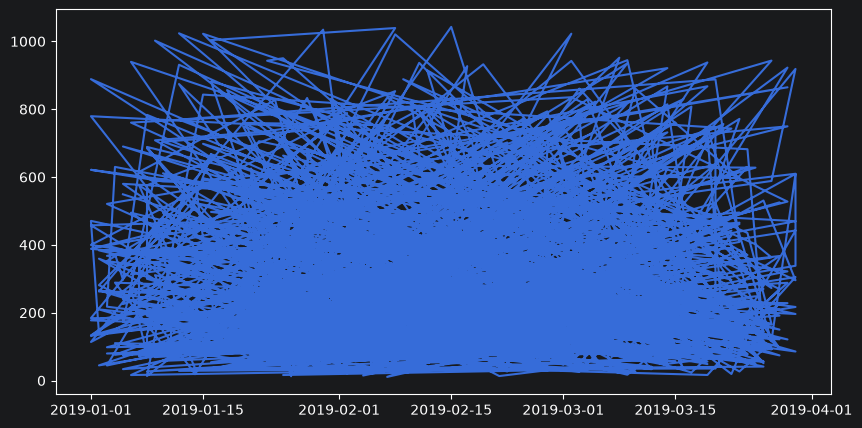

In [23]:
plt.figure(figsize=(10,5))
plt.plot(data['Date'], data['Total'])
plt.show()

In [26]:
trend = data.groupby('Date')['Total'].sum().reset_index()
trend.head()

,Date,Total
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


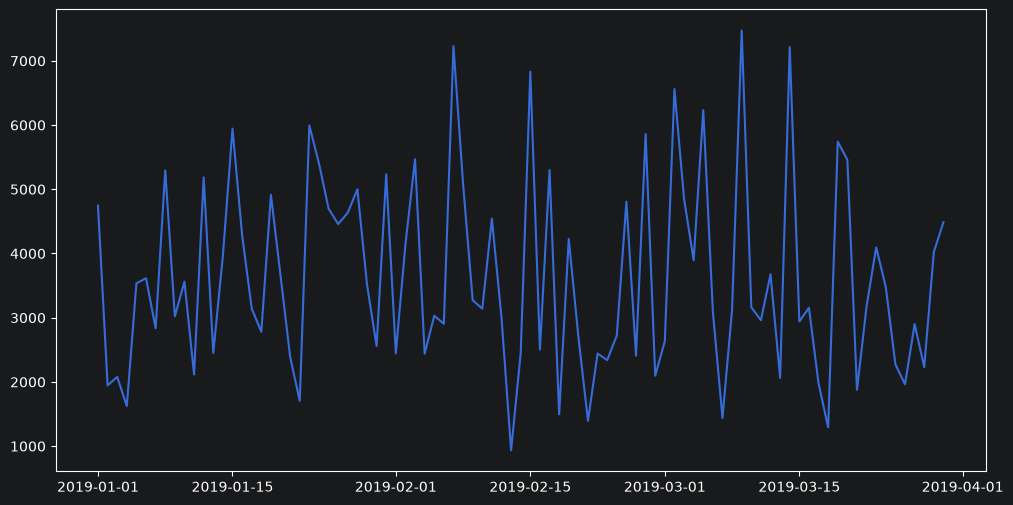

In [25]:
plt.figure(figsize=(12,6))
plt.plot(trend['Date'], trend['Total'])
plt.show()

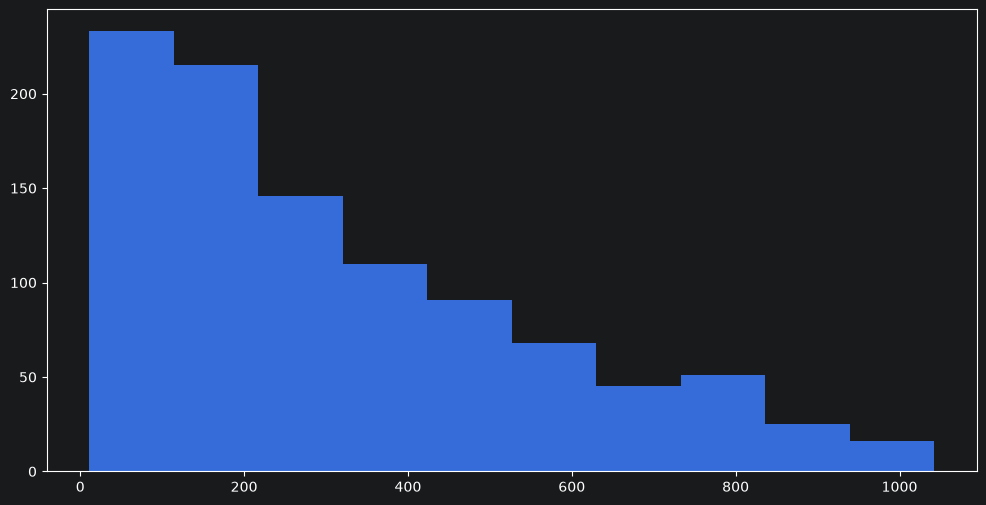

In [27]:
# Distribution of the total and the quantity
# Histograms
plt.figure(figsize=(12,6))
plt.hist(data['Total'])
plt.show()

TypeError: 'Axes' object is not subscriptable

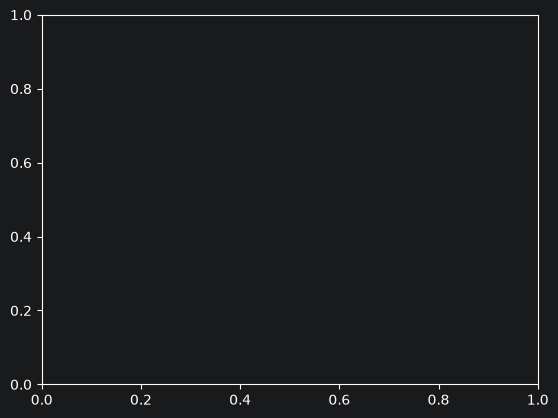

In [28]:
fig, ax = plt.subplots(1,2)
ax[0].hist(data['Total'])
ax[0].set_title(data['Total Distribution'])
ax[1].hist(data['Quantity'])
ax[1].set_title(data['Quantity Distribution'])
plt.show()

- Histograms
- Box Plots
- Violin Plots
- KDE Plots

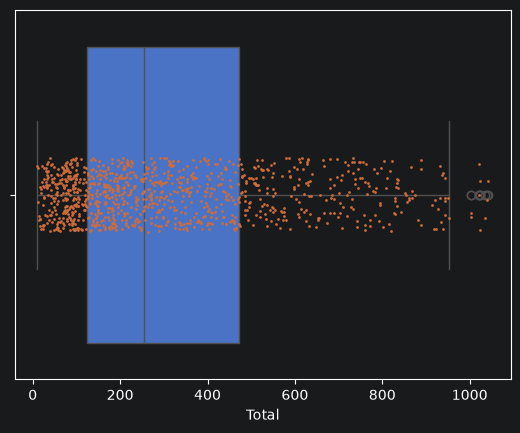

In [30]:
sns.boxplot(data['Total'], orient='h')
sns.stripplot(data=data, x='Total', size=2)
plt.show()

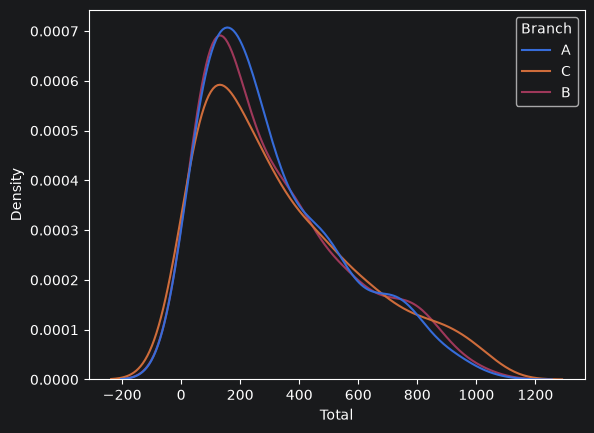

In [32]:
sns.kdeplot(data=data, x='Total', hue='Branch')
plt.show()

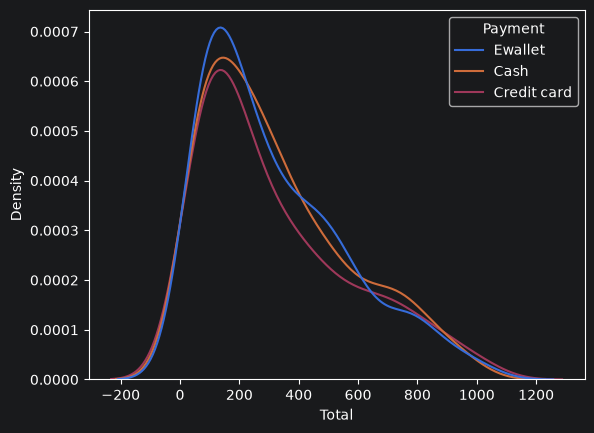

In [34]:
sns.kdeplot(data=data, x='Total', hue='Payment')
plt.show()

In [37]:
payment_sales = data.groupby('Payment')['Total'].sum().sort_values().reset_index()
payment_sales

,Payment,Total
0,Credit card,100767.072
1,Ewallet,109993.107
2,Cash,112206.570


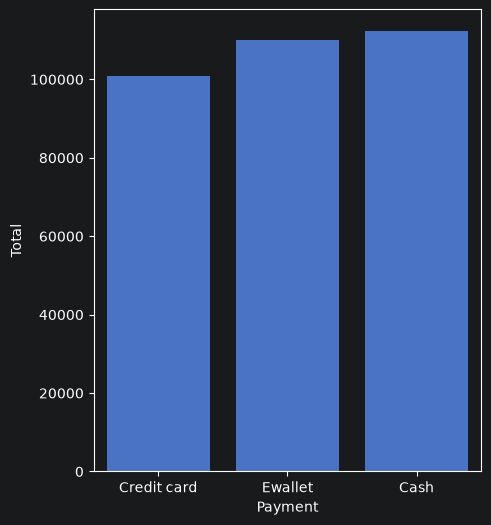

In [38]:
plt.figure(figsize=(5,6))
sns.barplot(payment_sales, x='Payment', y='Total')
plt.show()

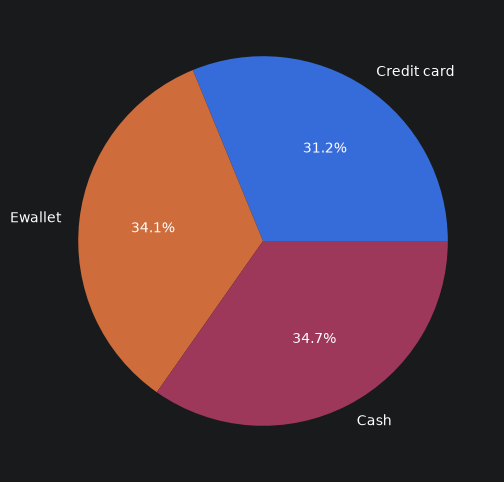

In [39]:
plt.figure(figsize=(6,6))
plt.pie(x=payment_sales['Total'], labels=payment_sales['Payment'], autopct='%1.1f%%')
plt.show()